In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
df_customers = pd.read_csv('./data/olist_customers_dataset.csv')
df_geolocation = pd.read_csv('./data/olist_geolocation_dataset.csv')
df_items = pd.read_csv('./data/olist_order_items_dataset.csv')
df_payments = pd.read_csv('./data/olist_order_payments_dataset.csv')
df_reviews = pd.read_csv('./data/olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('./data/olist_orders_dataset.csv')
df_products = pd.read_csv('./data/olist_products_dataset.csv')
df_sellers = pd.read_csv('./data/olist_sellers_dataset.csv')
df_category = pd.read_csv('./data/product_category_name_translation.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nCustomers: {df_customers.shape}")
print(f"Geolocation: {df_geolocation.shape}")
print(f"Items: {df_items.shape}")
print(f"Payments: {df_payments.shape}")
print(f"Reviews: {df_reviews.shape}")
print(f"Orders: {df_orders.shape}")
print(f"Products: {df_products.shape}")
print(f"Sellers: {df_sellers.shape}")
print(f"Category: {df_category.shape}")

데이터 로드 완료!

Customers: (99441, 5)
Geolocation: (1000163, 5)
Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category: (71, 2)


In [4]:
print("="*60)
print("데이터셋 정보:")
print("="*60)
print("\nCustomers:")
print(df_customers.info())

데이터셋 정보:

Customers:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None


In [5]:
print("\nGeolocation:")
print(df_geolocation.info())


Geolocation:
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB
None


In [6]:
print("\nItems:")
print(df_items.info())


Items:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB
None


In [7]:
print("\nPayments:")
print(df_payments.info())


Payments:
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB
None


In [8]:
print("\nreviews:")
print(df_reviews.info())


reviews:
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None


In [9]:
print("\norders:")
print(df_orders.info())


orders:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None


In [10]:
print("\nproducts:")
print(df_products.info())


products:
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None


In [11]:
print("\nsellers:")
print(df_sellers.info())


sellers:
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None


In [12]:
print("\ncategory:")
print(df_category.info())


category:
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
None


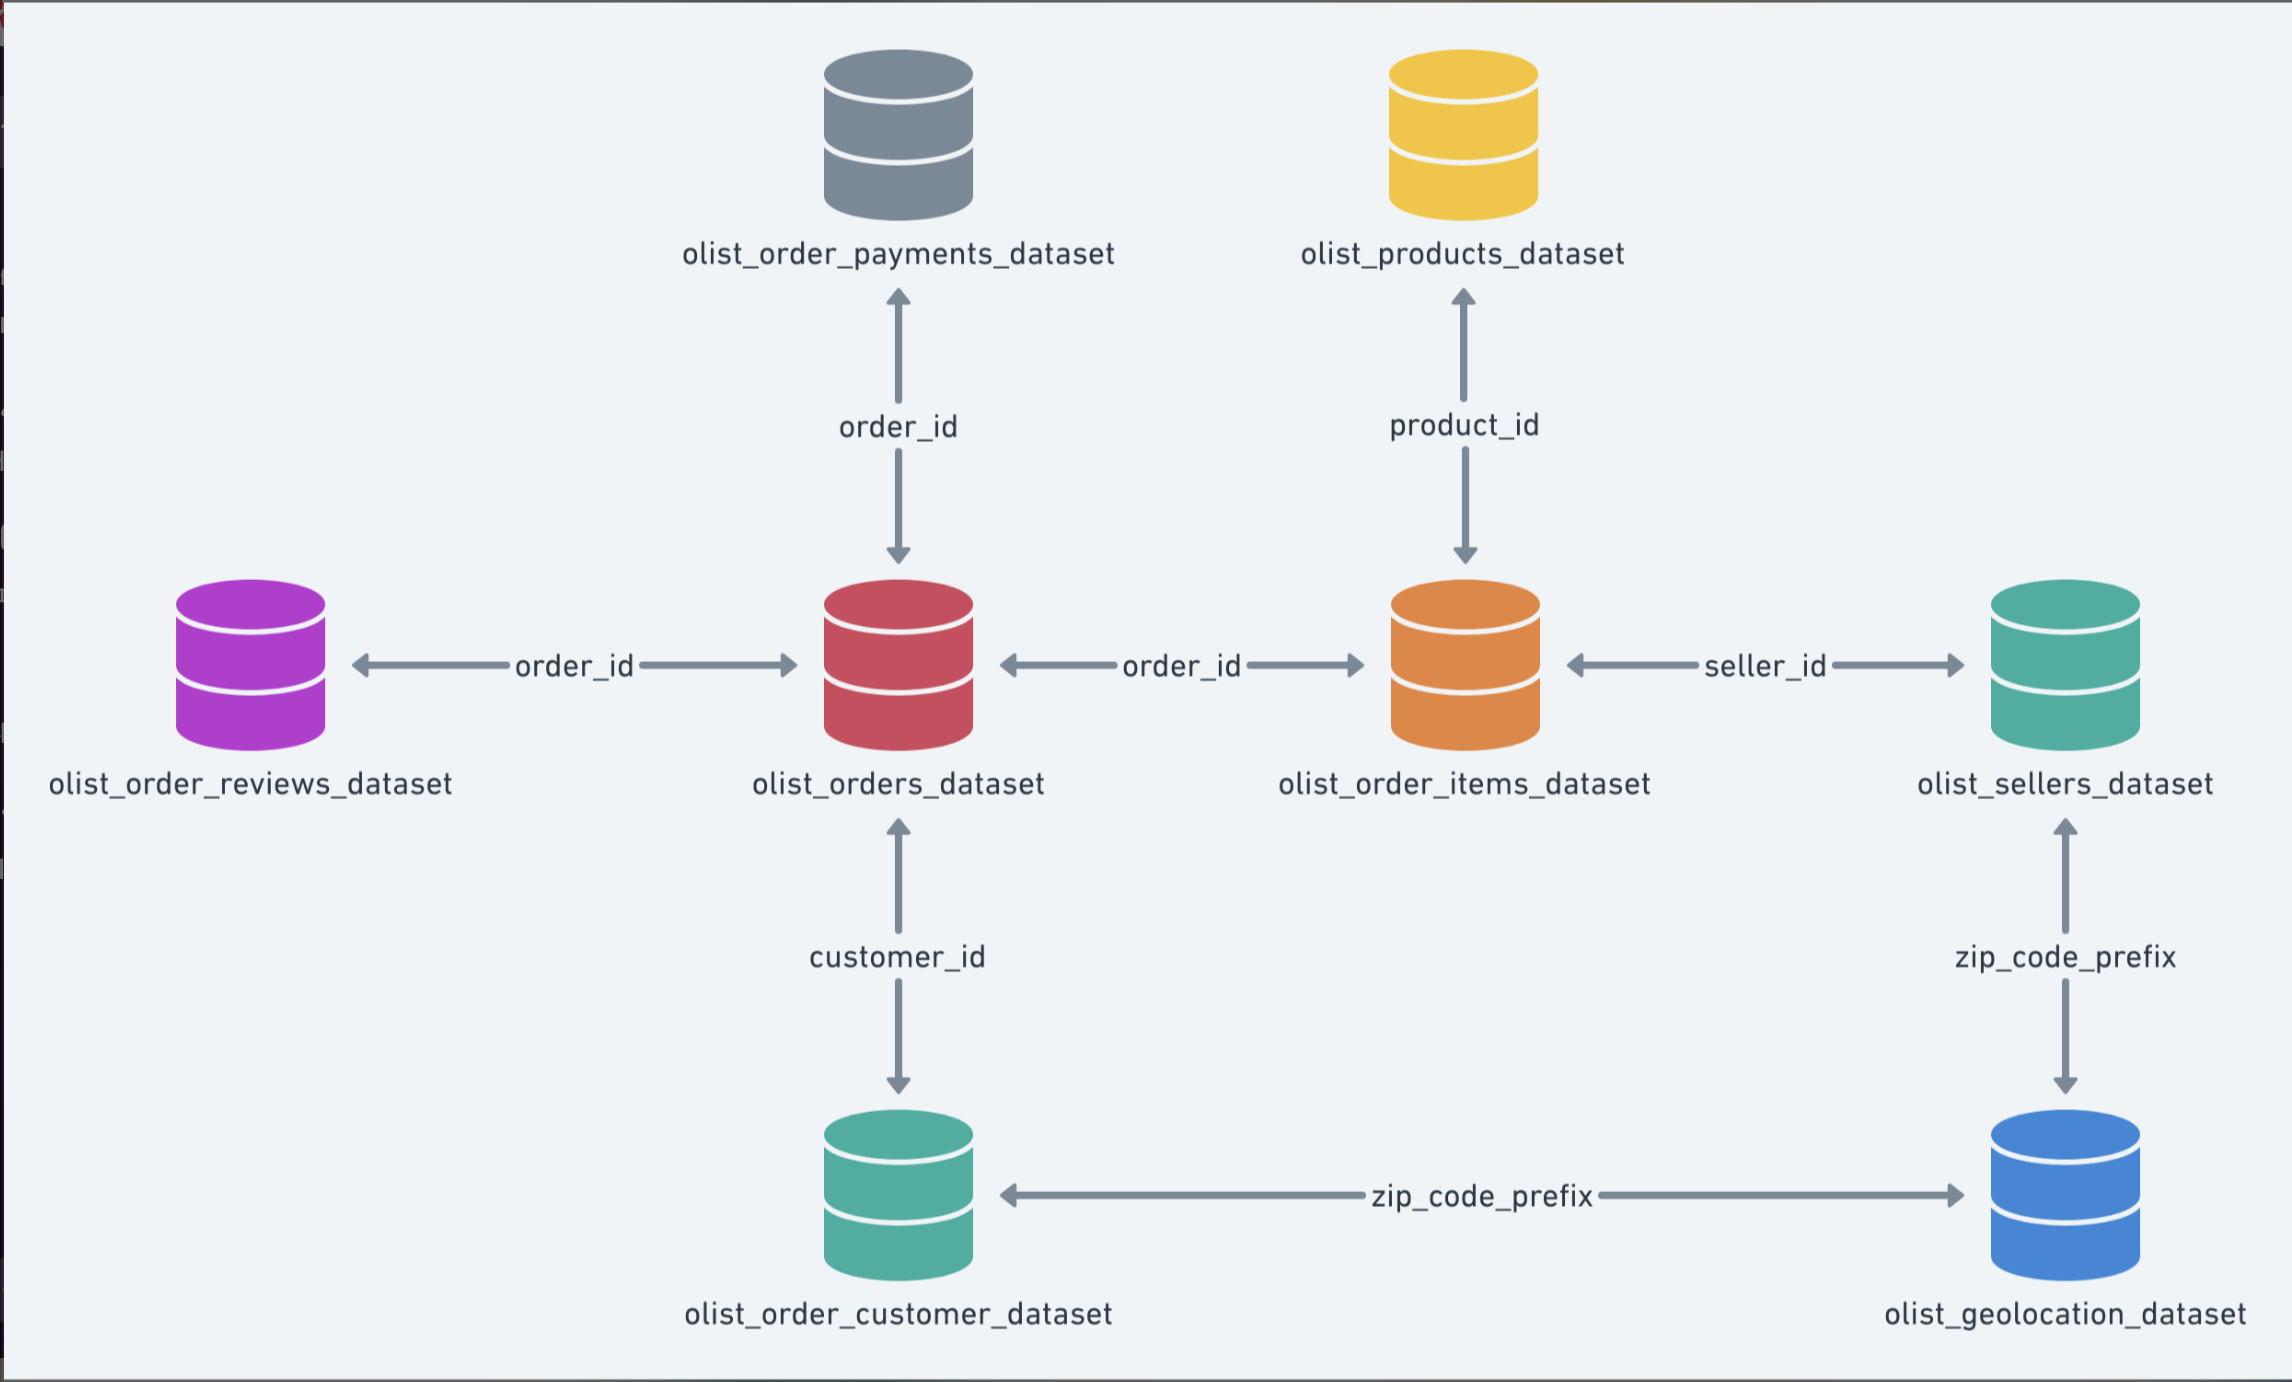

In [13]:
print("\n" + "="*60)
print("customers 기초 통계")
print("="*60)
display(df_customers.describe(include='all').T)


customers 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
print("geolocation 기초 통계")
display(df_geolocation.describe(include='all').T)

geolocation 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163.0,NaN,NaN,NaN,36574.166466,30549.33571,1001.0,11075.0,26530.0,63504.0,99990.0
geolocation_lat,1000163.0,NaN,NaN,NaN,-21.176153,5.715866,-36.605374,-23.603546,-22.919377,-19.97962,45.065933
geolocation_lng,1000163.0,NaN,NaN,NaN,-46.390541,4.269748,-101.466766,-48.573172,-46.637879,-43.767709,121.105394
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
print("items 기초 통계")
display(df_items.describe(include='all').T)

items 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,112650.0,NaN,NaN,NaN,1.197834,0.705124,1.0,1.0,1.0,1.0,21.0
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,112650,93318,2018-03-01 02:50:48,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,112650.0,NaN,NaN,NaN,120.653739,183.633928,0.85,39.9,74.99,134.9,6735.0
freight_value,112650.0,NaN,NaN,NaN,19.99032,15.806405,0.0,13.08,16.26,21.15,409.68


In [16]:
print("payments 기초 통계")
display(df_payments.describe(include='all').T)

payments 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,103886,99440,fa65dad1b0e818e3ccc5cb0e39231352,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_sequential,103886.0,NaN,NaN,NaN,1.092679,0.706584,1.0,1.0,1.0,1.0,29.0
payment_type,103886,5,credit_card,76795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,103886.0,NaN,NaN,NaN,2.853349,2.687051,0.0,1.0,1.0,4.0,24.0
payment_value,103886.0,NaN,NaN,NaN,154.10038,217.494064,0.0,56.79,100.0,171.8375,13664.08


In [17]:
print("reviews 기초 통계")
display(df_reviews.describe(include='all').T)

reviews 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,99224,98410,c444278834184f72b1484dfe47de7f97,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,99224,98673,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_score,99224.0,NaN,NaN,NaN,4.086421,1.347579,1.0,4.0,5.0,5.0,5.0
review_comment_title,11568,4527,Recomendo,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_comment_message,40977,36159,Muito bom,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_creation_date,99224,636,2017-12-19 00:00:00,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_answer_timestamp,99224,98248,2017-06-15 23:21:05,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
print("orders 기초 통계")
display(df_orders.describe(include='all').T)

orders 기초 통계


,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-03-31 15:08:21,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


In [19]:
print("products 기초 통계")
display(df_products.describe(include='all').T)

products 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,1e9e8ef04dbcff4541ed26657ea517e5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32341,73,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,32341.0,NaN,NaN,NaN,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,NaN,NaN,NaN,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,NaN,NaN,NaN,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,NaN,NaN,NaN,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,NaN,NaN,NaN,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,NaN,NaN,NaN,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,NaN,NaN,NaN,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0


In [20]:
print("sellers 기초 통계")
display(df_sellers.describe(include='all').T)

sellers 기초 통계


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,3095.0,NaN,NaN,NaN,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
print("category 기초 통계")
display(df_category.describe(include='all').T)

category 기초 통계


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


In [22]:
print("customers 데이터 샘플")
display(df_customers.head(10))

customers 데이터 샘플


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [23]:
print("geolocation 데이터 샘플")
display(df_geolocation.head(10))

geolocation 데이터 샘플


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
5,1012,-23.547762,-46.635361,são paulo,SP
6,1047,-23.546273,-46.641225,sao paulo,SP
7,1013,-23.546923,-46.634264,sao paulo,SP
8,1029,-23.543769,-46.634278,sao paulo,SP
9,1011,-23.547640,-46.636032,sao paulo,SP


In [24]:
print("items 데이터 샘플")
display(df_items.head(10))

items 데이터 샘플


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [25]:
print("payments 데이터 샘플")
display(df_payments.head(10))

payments 데이터 샘플


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [26]:
## 할부 횟수가 0인 payments 데이터 2건 삭제 (payment_installments==0)
print(f"2건 삭제 전 payments 행 개수 : {len(df_payments)}")
df_payments = df_payments[df_payments['payment_installments'] != 0]
print(f"2건 삭제 후 payments 행 개수 : {len(df_payments)}")
# 2건 삭제 전 payments 행 개수 : 103886
# 2건 삭제 후 payments 행 개수 : 103884

2건 삭제 전 payments 행 개수 : 103886
2건 삭제 후 payments 행 개수 : 103884


In [27]:
print("reviews 데이터 샘플")
display(df_reviews.head(10))

reviews 데이터 샘플


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta uma vez que é o mesmo aparelho,2018-05-22 00:00:00,2018-05-23 16:45:47


In [28]:
print("orders 데이터 샘플")
display(df_orders.head(10))

orders 데이터 샘플


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [29]:
print("products 데이터 샘플")
display(df_products.head(10))

products 데이터 샘플


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [30]:
print("sellers 데이터 샘플")
display(df_sellers.head(10))

sellers 데이터 샘플


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
5,c240c4061717ac1806ae6ee72be3533b,20920,rio de janeiro,RJ
6,e49c26c3edfa46d227d5121a6b6e4d37,55325,brejao,PE
7,1b938a7ec6ac5061a66a3766e0e75f90,16304,penapolis,SP
8,768a86e36ad6aae3d03ee3c6433d61df,1529,sao paulo,SP
9,ccc4bbb5f32a6ab2b7066a4130f114e3,80310,curitiba,PR


In [31]:
print("category 데이터 샘플")
display(df_category.head(10))

category 데이터 샘플


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


## 데이터 전처리

In [32]:
print("중복데이터 확인")

# 전체 행 중복 확인
print("전체 행 중복 확인")
print(f"customers 중복 행 수: {df_customers.duplicated().sum()}")
print(f"geolocation 중복 행 수: {df_geolocation.duplicated().sum()}")
print(f"items 중복 행 수: {df_items.duplicated().sum()}")
print(f"payments 중복 행 수: {df_payments.duplicated().sum()}")
print(f"reviews 중복 행 수: {df_reviews.duplicated().sum()}")
print(f"orders 중복 행 수: {df_orders.duplicated().sum()}")
print(f"products 중복 행 수: {df_products.duplicated().sum()}")
print(f"sellers 중복 행 수: {df_sellers.duplicated().sum()}")
print(f"category 중복 행 수: {df_category.duplicated().sum()}")

# geolocation 중복 데이터 제거
print(f"\n제거 전 geolocation 행 수: {len(df_geolocation)}")
df_geolocation.drop_duplicates(inplace=True)
print(f"제거 후 geolocation 행 수: {len(df_geolocation)}\n")

중복데이터 확인
전체 행 중복 확인
customers 중복 행 수: 0
geolocation 중복 행 수: 261831
items 중복 행 수: 0
payments 중복 행 수: 0
reviews 중복 행 수: 0
orders 중복 행 수: 0
products 중복 행 수: 0
sellers 중복 행 수: 0
category 중복 행 수: 0

제거 전 geolocation 행 수: 1000163
제거 후 geolocation 행 수: 738332



### 이상치 처리

In [33]:
# 타임라인 검증 함수

def check_order_timeline(df, show_rows=False):
    """
    delivered 주문만 대상으로 타임라인 이상 여부 점검
    show_rows=True로 설정하면 이상 행도 함께 출력
    """

    total = len(df)

    checks = {
        "purchase > approved" : (df['order_purchase_timestamp'] > df['order_approved_at']),
        "approved > carrier" : (df['order_approved_at'] > df['order_delivered_carrier_date']),
        "carrier > delivered" : (df['order_delivered_carrier_date'] > df['order_delivered_customer_date']),
        "delivered < purchase" : (df['order_delivered_customer_date'] < df['order_purchase_timestamp'])
    }

    for name, check in checks.items():

        error_df = df[check]    # 이상 행 추출
        count = len(error_df)   # 이상 행 기수

        print(f'{name}: {count}건')

        if show_rows and count > 0:
            display(error_df.head())

In [34]:
# 타임라인 검증 함수 활용
check_order_timeline(df_orders, show_rows=True)

purchase > approved: 0건
approved > carrier: 1359건


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04 00:00:00
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15 00:00:00
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19,2018-07-31 00:00:00
210,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42,2018-07-31 00:00:00
415,56a4ac10a4a8f2ba7693523bb439eede,78438ba6ace7d2cb023dbbc81b083562,delivered,2018-07-22 13:04:47,2018-07-27 23:31:09,2018-07-24 14:03:00,2018-07-28 00:05:39,2018-08-06 00:00:00


carrier > delivered: 23건


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14 00:00:00
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21 00:00:00
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08 00:00:00
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11 00:00:00
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31 00:00:00


delivered < purchase: 0건


In [35]:
print(f"물건이 택배사에 전달된 날짜가 고객에게 도착한 날짜보다 이후인 23건 제거") 
print(f"23건 제거 전 행 수 {len(df_orders)}") # 99441
df_orders = df_orders[~(df_orders['order_delivered_carrier_date']>df_orders['order_delivered_customer_date'])] 
print(f"23건 제거 후 행 수 {len(df_orders)}") # 99418

물건이 택배사에 전달된 날짜가 고객에게 도착한 날짜보다 이후인 23건 제거
23건 제거 전 행 수 99441
23건 제거 후 행 수 99418


### 결측치 처리

In [36]:
# 결측치 확인
print("결측치 확인")
print(f"customers 결측치:\n{df_customers.isnull().sum()}\n")
print(f"geolocation 결측치:\n{df_geolocation.isnull().sum()}\n")
print(f"items 결측치:\n{df_items.isnull().sum()}\n")
print(f"payments 결측치:\n{df_payments.isnull().sum()}\n")
print(f"reviews 결측치:\n{df_reviews.isnull().sum()}\n")
print(f"orders 결측치:\n{df_orders.isnull().sum()}\n")
print(f"products 결측치:\n{df_products.isnull().sum()}\n")
print(f"sellers 결측치:\n{df_sellers.isnull().sum()}\n")
print(f"category 결측치:\n{df_category.isnull().sum()}\n")

결측치 확인
customers 결측치:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

geolocation 결측치:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

items 결측치:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

payments 결측치:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

reviews 결측치:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

or

#### reviews 데이터 결측치 확인

In [37]:
# reviews 데이터의 review_comment_title과 review_comment_message 컬럼의 결측치를 'None'으로 대체
print(f"reviews 결측치:\n{df_reviews.isnull().sum()}\n")

df_reviews['review_comment_title'] = df_reviews['review_comment_title'].fillna('None')
df_reviews['review_comment_message'] = df_reviews['review_comment_message'].fillna('None')

print("결측치 처리 후 reviews 데이터 결측치 확인")
print(f"reviews 결측치:\n{df_reviews.isnull().sum()}\n")

reviews 결측치:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

결측치 처리 후 reviews 데이터 결측치 확인
reviews 결측치:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64



#### orders 데이터 결측치 확인

In [38]:
# 'order_status' == 'delivered'인 행만 추출
print(f"delivered 추출 전 order 테이블 행 개수: {len(df_orders)}") # 99418
df_orders = df_orders[df_orders['order_status']=='delivered']
print(f"delivered 추출 후 order 테이블 행 개수: {len(df_orders)}") # 96455
df_orders.head()
# delivered 추출 전 order 테이블 행 개수: 99418
# delivered 추출 후 order 테이블 행 개수: 96455

delivered 추출 전 order 테이블 행 개수: 99418
delivered 추출 후 order 테이블 행 개수: 96455


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [39]:
# orders 데이터 결측치 확인
print(f"orders 결측치:\n{df_orders.isnull().sum()}\n")

print(f"approved at 결측치: {df_orders['order_approved_at'].isna().sum()}")
print(f"delivered carrier date 결측치: {df_orders['order_delivered_carrier_date'].isna().sum()}")
print(f"delivered customer date 결측치: {df_orders['order_delivered_customer_date'].isna().sum()}")

orders 결측치:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

approved at 결측치: 14
delivered carrier date 결측치: 2
delivered customer date 결측치: 8


In [40]:
# orders 데이터의 order_approved_at, order_delivered_carrier_date, order_delivered_customer_date 컬럼의 결측치를 제거
df_orders.dropna(subset=['order_approved_at', 
                         'order_delivered_carrier_date', 
                         'order_delivered_customer_date'], inplace=True)

print("결측치 처리 후 orders 데이터 결측치 확인")
print(f"orders 결측치:\n{df_orders.isnull().sum()}\n")
print(f"orders 결측치 제거 후 order 테이블 행 개수: {len(df_orders)}")

결측치 처리 후 orders 데이터 결측치 확인
orders 결측치:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

orders 결측치 제거 후 order 테이블 행 개수: 96432


In [41]:
# 데이터 타입 변환
print("데이터 타입 변환")
# orders 데이터의 order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date 컬럼을 datetime 타입으로 변환
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at'] = pd.to_datetime(df_orders['order_approved_at'])
df_orders['order_delivered_carrier_date'] = pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])

# reviews 데이터의 review_creation_date와 review_answer_timestamp 컬럼을 datetime 타입으로 변환
df_reviews['review_creation_date'] = pd.to_datetime(df_reviews['review_creation_date'])
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'])

# items 데이터의 shipping_limit_date 컬럼을 datetime 타입으로 변환
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

print("데이터 타입 변환 완료!")

데이터 타입 변환
데이터 타입 변환 완료!


In [42]:
# 전처리 후 데이터셋 정보 확인
print("\n전처리 후 데이터셋 정보:")
print("="*60)
print("\nCustomers:")
print(df_customers.info())


전처리 후 데이터셋 정보:

Customers:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None


In [43]:
print("\nGeolocation:")
print(df_geolocation.info()) # geolocation 테이블 제거할 예정


Geolocation:
<class 'pandas.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  str    
 4   geolocation_state            738332 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 33.8 MB
None


In [44]:
print("\nitems:")
print(df_items.info())


items:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB
None


In [45]:
print("\nPayments:")
print(df_payments.info()) # payments 테이블 제거할 예정


Payments:
<class 'pandas.DataFrame'>
Index: 103884 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103884 non-null  str    
 1   payment_sequential    103884 non-null  int64  
 2   payment_type          103884 non-null  str    
 3   payment_installments  103884 non-null  int64  
 4   payment_value         103884 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.8 MB
None


In [46]:
print("\nReviews:")
print(df_reviews.info()) 


Reviews:
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  str           
 4   review_comment_message   99224 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB
None


In [47]:
print("\norders:")
print(df_orders.info())


orders:
<class 'pandas.DataFrame'>
Index: 96432 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96432 non-null  str           
 1   customer_id                    96432 non-null  str           
 2   order_status                   96432 non-null  str           
 3   order_purchase_timestamp       96432 non-null  datetime64[us]
 4   order_approved_at              96432 non-null  datetime64[us]
 5   order_delivered_carrier_date   96432 non-null  datetime64[us]
 6   order_delivered_customer_date  96432 non-null  datetime64[us]
 7   order_estimated_delivery_date  96432 non-null  str           
dtypes: datetime64[us](4), str(4)
memory usage: 6.6 MB
None


In [48]:
print("\nproducts:")
print(df_products.info())


products:
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
None


In [49]:
print("\nsellers:")
print(df_sellers.info())


sellers:
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB
None


In [50]:
print("\ncategory:")
print(df_category.info())


category:
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB
None


In [51]:
# geolocation 테이블의 일부 컬럼 제거
col_remove = ['geolocation_city','geolocation_state']
df_geolocation = df_geolocation.drop(columns=col_remove)

In [52]:
# reviews 테이블의 일부 컬럼 제거 
col_remove = ['review_comment_title','review_comment_message','review_creation_date']
df_reviews = df_reviews.drop(columns=col_remove)

In [53]:
# orders 테이블의 일부 컬럼 제거 
col_remove = ['order_status']
df_orders = df_orders.drop(columns=col_remove)

In [54]:
# products 테이블의 일부 컬럼 제거 
col_remove = ['product_name_lenght','product_description_lenght','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','product_width_cm']
df_products = df_products.drop(columns=col_remove)

## 테이블 병합 MERGE

#### products 테이블

In [55]:
# 1. 카테고리 영문명 변환 및 정리
df_products = pd.merge(df_products, df_category, on="product_category_name", how="left")
df_products = df_products.drop(columns=["product_category_name"]) # 원본 컬럼 삭제

In [56]:
df_products.head()

,product_id,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares


#### geolocation 테이블

In [57]:
# 그룹화되기 전 geolocation 데이터 확인
print("\n그룹화되기 전 geolocation 데이터:")
print(df_geolocation.info())

# 데이터 증식 방지 그룹화
print("\n데이터 증식 방지 그룹화")
# geolocation 데이터는 중복된 지리 정보가 많으므로, geolocation_zip_code_prefix를 기준으로 그룹화하여 고유한 지리 정보만 남깁니다.
df_geo_unique = df_geolocation.groupby('geolocation_zip_code_prefix').agg({
'geolocation_lat': 'mean',
'geolocation_lng': 'mean'
}).reset_index()

# 그룹화된 geolocation 데이터 확인
print("\n그룹화된 geolocation 데이터:")
print(df_geo_unique.info())

# 그룹화된 geolocation 데이터 샘플
print("\n그룹화된 geolocation 데이터 샘플:")
display(df_geo_unique.head(10))


그룹화되기 전 geolocation 데이터:
<class 'pandas.DataFrame'>
Index: 738332 entries, 0 to 1000161
Data columns (total 3 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 22.5 MB
None

데이터 증식 방지 그룹화

그룹화된 geolocation 데이터:
<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 445.8 KB
None

그룹화된 geolocation 데이터 샘플:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550227,-46.634039
1,1002,-23.547657,-46.634991
2,1003,-23.549000,-46.635582
3,1004,-23.549829,-46.634792
4,1005,-23.549547,-46.636406
5,1006,-23.550127,-46.636044
6,1007,-23.549962,-46.637204
7,1008,-23.546000,-46.635877
8,1009,-23.546891,-46.636498
9,1010,-23.546667,-46.635404


In [58]:
df_geo_unique['geolocation_zip_code_prefix'] = df_geo_unique['geolocation_zip_code_prefix'].astype(str)

In [59]:
# customers 데이터에 geolocation 데이터 병합
print("\ncustomers 데이터에 geolocation 데이터 병합")
# customers 데이터에 geolocation 데이터를 병합하기 위해, customer_zip_code_prefix와 geolocation_zip_code_prefix를 기준으로 병합
df_customers['customer_zip_code_prefix'] = df_customers['customer_zip_code_prefix'].astype(str)

df_customers_geo = pd.merge(df_customers, df_geo_unique,
left_on='customer_zip_code_prefix',
right_on='geolocation_zip_code_prefix',
how='left')

# 불필요한 조인 키 삭제 및 고객 접두사 추가
df_customers_geo = df_customers_geo.drop(columns=['geolocation_zip_code_prefix'])
df_customers_geo = df_customers_geo.rename(columns={
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
})

# 병합된 데이터 확인
print("\n병합된 customers 데이터:")
print(df_customers_geo.info())
# 병합된 데이터 샘플
print("\n병합된 customers 데이터 샘플:")
display(df_customers_geo.head(10))


customers 데이터에 geolocation 데이터 병합

병합된 customers 데이터:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               99441 non-null  str    
 1   customer_unique_id        99441 non-null  str    
 2   customer_zip_code_prefix  99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   customer_lat              99163 non-null  float64
 6   customer_lng              99163 non-null  float64
dtypes: float64(2), str(5)
memory usage: 5.3 MB
None

병합된 customers 데이터 샘플:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.499273,-47.396658
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.728396,-46.542250
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531309,-46.656690
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.500670,-46.186348
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975708,-47.143140
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC,-26.470766,-49.115690
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP,-23.584468,-46.674959
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG,-19.576407,-42.643525
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR,-25.486533,-49.217764
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG,-19.973066,-43.972776


In [60]:
df_customers_geo.isna().sum()

customer_id                   0
customer_unique_id            0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
customer_lat                278
customer_lng                278
dtype: int64

In [61]:
df_customers_geo[df_customers_geo['customer_lat'].isna()].head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng
354,ecb1725b26e8b8c458181455dfa434ea,b55a113bb84fc10eaf58c6d09ec69794,72300,brasilia,DF,NaN,NaN
382,bcf86029aeed4ed8bac0e16eb14c22f5,7cd7974c9f79f75b77f323878ef87f43,11547,cubatao,SP,NaN,NaN
877,f4302056f0c58570522590f8181de2c7,67b05b597a66b5c449025000b9430abb,64605,picos,PI,NaN,NaN
1218,03bbe0ce5c28e05f22917607db798818,8f3dca4306d5a89e4ae2c65c110603a2,72465,brasilia,DF,NaN,NaN
1272,ad4950aded55c2ea376be59506456d68,aa2b96dd03307ea6dc4b763c0b5f0b39,7729,caieiras,SP,NaN,NaN


In [62]:
# sellers 데이터에 geolocation 데이터 병합
print("\nsellers 데이터에 geolocation 데이터 병합")
# sellers 데이터에 geolocation 데이터를 병합하기 위해, seller_zip_code_prefix와 geolocation_zip_code_prefix를 기준으로 병합
df_sellers['seller_zip_code_prefix'] = df_sellers['seller_zip_code_prefix'].astype(str)

df_sellers_geo = pd.merge(df_sellers, df_geo_unique,
left_on='seller_zip_code_prefix',
right_on='geolocation_zip_code_prefix',
how='left')

# 불필요한 조인 키 삭제 및 고객 접두사 추가
df_sellers_geo = df_sellers_geo.drop(columns=['geolocation_zip_code_prefix'])
df_sellers_geo = df_sellers_geo.rename(columns={
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
})

# 병합된 데이터 확인
print("\n병합된 sellers 데이터:")
print(df_sellers_geo.info())
# 병합된 데이터 샘플
print("\n병합된 sellers 데이터 샘플:")
display(df_sellers_geo.head(10))


sellers 데이터에 geolocation 데이터 병합

병합된 sellers 데이터:
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seller_id               3095 non-null   str    
 1   seller_zip_code_prefix  3095 non-null   str    
 2   seller_city             3095 non-null   str    
 3   seller_state            3095 non-null   str    
 4   seller_lat              3088 non-null   float64
 5   seller_lng              3088 non-null   float64
dtypes: float64(2), str(4)
memory usage: 145.2 KB
None

병합된 sellers 데이터 샘플:


,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,-22.893317,-47.060596
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,-22.383375,-46.948142
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,-22.909446,-43.180240
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,-23.657118,-46.612730
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,-22.964546,-46.534214
5,c240c4061717ac1806ae6ee72be3533b,20920,rio de janeiro,RJ,-22.895420,-43.230347
6,e49c26c3edfa46d227d5121a6b6e4d37,55325,brejao,PE,-9.024839,-36.570200
7,1b938a7ec6ac5061a66a3766e0e75f90,16304,penapolis,SP,-21.436452,-50.077136
8,768a86e36ad6aae3d03ee3c6433d61df,1529,sao paulo,SP,-23.568374,-46.634471
9,ccc4bbb5f32a6ab2b7066a4130f114e3,80310,curitiba,PR,-25.456890,-49.309772


### reviews 테이블 중복 처리

In [63]:
# 리뷰 응답 시간을 기준으로 정렬 후, order_id가 중복되면 마지막(최신) 데이터만 남김
df_reviews = df_reviews.sort_values(by=['order_id', 'review_answer_timestamp'])
df_reviews = df_reviews.drop_duplicates(subset=['order_id'], keep='last')

In [64]:
# 4. 최종 통합 (orders 중심으로)
df_final = pd.merge(df_orders, df_customers_geo, on="customer_id", how="left")
df_final = pd.merge(df_final, df_items, on="order_id", how="left")
df_final = pd.merge(df_final, df_reviews, on="order_id", how="left")
df_final = pd.merge(df_final, df_products, on="product_id", how="left")
df_final = pd.merge(df_final, df_sellers_geo, on="seller_id", how="left")

In [65]:
# 최종 컬럼 구성 확인
print(df_final.columns.tolist())

# 최종 행 수 확인
print(len(df_final))

['order_id', 'customer_id', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_id', 'review_score', 'review_answer_timestamp', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng']
110123


In [66]:
df_final.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_answer_timestamp,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-12 03:43:48,housewares,9350,maua,SP,-23.680862,-46.444311
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.186877,-44.540232,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,8d5266042046a06655c8db133d120ba5,4.0,2018-08-08 18:37:50,perfumery,31570,belo horizonte,SP,-19.807885,-43.980818
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,e73b67b67587f7644d5bd1a52deb1b01,5.0,2018-08-22 19:07:58,auto,14840,guariba,SP,-21.363473,-48.229588
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774002,-35.270976,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,359d03e676b3c069f62cadba8dd3f6e8,5.0,2017-12-05 19:21:58,pet_shop,31842,belo horizonte,MG,-19.836871,-43.923241
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.676257,-46.514580,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,e50934924e227544ba8246aeb3770dd4,5.0,2018-02-18 13:02:51,stationery,8752,mogi das cruzes,SP,-23.541525,-46.262148


In [67]:
missing_info = pd.DataFrame({
'Missing Values': df_final.isnull().sum(),
'Percentage (%)': (df_final.isnull().sum() / len(df_final)) * 100
})
print("컬럼별 결측치 현황")
print(missing_info[missing_info['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))

컬럼별 결측치 현황
                               Missing Values  Percentage (%)
product_category_name_english            1557        1.413874
review_id                                 827        0.750978
review_score                              827        0.750978
review_answer_timestamp                   827        0.750978
customer_lat                              288        0.261526
customer_lng                              288        0.261526
seller_lat                                249        0.226111
seller_lng                                249        0.226111


In [68]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 110123 entries, 0 to 110122
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110123 non-null  str           
 1   customer_id                    110123 non-null  str           
 2   order_purchase_timestamp       110123 non-null  datetime64[us]
 3   order_approved_at              110123 non-null  datetime64[us]
 4   order_delivered_carrier_date   110123 non-null  datetime64[us]
 5   order_delivered_customer_date  110123 non-null  datetime64[us]
 6   order_estimated_delivery_date  110123 non-null  str           
 7   customer_unique_id             110123 non-null  str           
 8   customer_zip_code_prefix       110123 non-null  str           
 9   customer_city                  110123 non-null  str           
 10  customer_state                 110123 non-null  str           
 11  customer_la

In [69]:
df_final.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,110123,96432,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,110123,96432,fc3d1daec319d62d49bfb5e1f83123e9,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,110123,NaN,NaN,NaN,2018-01-02 06:08:29.027379,2016-09-15 12:16:38,2017-09-15 12:46:05.500000,2018-01-21 12:29:50,2018-05-05 16:46:23.500000,2018-08-29 15:00:37,NaN
order_approved_at,110123,NaN,NaN,NaN,2018-01-02 16:39:35.304977,2016-09-15 12:16:38,2017-09-15 19:07:13.500000,2018-01-22 13:59:37,2018-05-06 00:14:15,2018-08-29 15:10:26,NaN
order_delivered_carrier_date,110123,NaN,NaN,NaN,2018-01-05 12:52:50.099361,2016-10-08 10:34:01,2017-09-19 14:08:48,2018-01-24 19:37:16,2018-05-08 14:27:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,110123,NaN,NaN,NaN,2018-01-14 17:31:55.162136,2016-10-11 13:46:32,2017-09-26 21:39:12,2018-02-02 22:26:42,2018-05-15 20:39:00.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,110123,445,2017-12-20 00:00:00,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,110123,93316,c8460e4251689ba205045f3ea17884a1,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,110123,14889,22790,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,110123,4085,sao paulo,17388,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
# 전처리 완료
print("\n1차 전처리 완료!")
# 최종 데이터셋 저장
df_final.to_csv('./data/merged_data.csv', index=False)


1차 전처리 완료!


### 2차 전처리 시작

In [71]:
df = pd.read_csv('./data/merged_data.csv')

In [72]:
df2 = df.copy()

In [73]:
df2.isna().sum()

order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
customer_lat                      288
customer_lng                      288
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
review_id                         827
review_score                      827
review_answer_timestamp           827
product_category_name_english    1557
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
seller_lat  

## 결측치 처리

### review_score 결측치

In [74]:
# review_score 컬럼 결측치 제거
print(f"제거 전 데이터 개수: {len(df2)}") # 110123
df2 = df2.dropna(subset=['review_score']).reset_index()
print(f"제거 후 데이터 개수: {len(df2)}") # 109296

제거 전 데이터 개수: 110123
제거 후 데이터 개수: 109296


In [75]:
df2['review_score'].value_counts()

review_score
5.0    62924
4.0    21052
1.0    12472
3.0     9187
2.0     3661
Name: count, dtype: int64

In [76]:
# 데이터 전처리 (리뷰 점수 정수화)
df2['review_score'] = df2['review_score'].astype(int)

### customer 위도 경도 결측치
#### customer_city별 위도 경도 최빈값으로 대체

In [77]:
# 고객(Customer) 데이터 결측치 대체 예시
# transform 내부에서 mode()를 계산할 때, 빈 Series가 반환될 경우와 다중 최빈값이 나올 경우를 대비해 처리
fill_lat_customer = df2.groupby('customer_city')['customer_lat'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
fill_lng_customer = df2.groupby('customer_city')['customer_lng'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

df2['customer_lat'] = df2['customer_lat'].fillna(fill_lat_customer)
df2['customer_lng'] = df2['customer_lng'].fillna(fill_lng_customer)

### seller 위도 경도 결측치
#### seller_city별 위도 경도 최빈값으로 대체

In [78]:
# 판매자(Seller) 데이터 결측치 대체
# transform 내부에서 mode()를 계산할 때, 빈 Series가 반환될 경우와 다중 최빈값이 나올 경우를 대비해 처리
fill_lat_seller = df2.groupby('seller_city')['seller_lat'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)
fill_lng_seller = df2.groupby('seller_city')['seller_lng'].transform(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

df2['seller_lat'] = df2['seller_lat'].fillna(fill_lat_seller)
df2['seller_lng'] = df2['seller_lng'].fillna(fill_lng_seller)

In [79]:
df2.isna().sum()

index                               0
order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
customer_lat                       49
customer_lng                       49
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
review_id                           0
review_score                        0
review_answer_timestamp             0
product_category_name_english    1545
seller_zip_code_prefix              0
seller_city                         0
seller_state

## 파생컬럼 생성

In [80]:
df2['order_purchase_timestamp'] = pd.to_datetime(df2['order_purchase_timestamp'])
df2['order_delivered_customer_date'] = pd.to_datetime(df2['order_delivered_customer_date'])
df2['order_estimated_delivery_date'] = pd.to_datetime(df2['order_estimated_delivery_date'])
df2['order_approved_at'] = pd.to_datetime(df2['order_approved_at'])
df2['order_delivered_carrier_date'] = pd.to_datetime(df2['order_delivered_carrier_date'])

# 주문 시점의 요일 정보 추가
df2['order_purchase_dayofweek'] = df2['order_purchase_timestamp'].dt.dayofweek
df2['order_purchase_dayofweek'] = df2['order_purchase_dayofweek'].map({
0: 'monday',
1: 'tuesday',
2: 'wednesday',
3: 'thursday',
4: 'friday',
5: 'saturday',
6: 'sunday'
})
# 요일 순서 정의 
weekday_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# 데이터를 범주형(Categorical)으로 변환하여 순서 부여
# 이렇게 하면 groupby를 해도 이 순서가 유지됨
df2['order_purchase_dayofweek'] = pd.Categorical(df2['order_purchase_dayofweek'], 
                                                categories=weekday_order, 
                                                ordered=True)

# 주문 시점의 월 정보 추가
df2['order_purchase_month'] = df2['order_purchase_timestamp'].dt.month
df2['order_purchase_month'] = df2['order_purchase_month'].astype('category')
df2['order_purchase_month'] = df2['order_purchase_month'].cat.set_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
df2['order_purchase_month'] = df2['order_purchase_month'].cat.codes
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)
df2['order_purchase_month'] = df2['order_purchase_month'].map({
0: 1,
1: 2,
2: 3,
3: 4,
4: 5,
5: 6,
6: 7,
7: 8,
8: 9,
9: 10,
10: 11,
11: 12
})
df2['order_purchase_month'] = df2['order_purchase_month'].astype(int)

df2.info()
df2.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 109296 entries, 0 to 109295
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   index                          109296 non-null  int64         
 1   order_id                       109296 non-null  str           
 2   customer_id                    109296 non-null  str           
 3   order_purchase_timestamp       109296 non-null  datetime64[us]
 4   order_approved_at              109296 non-null  datetime64[us]
 5   order_delivered_carrier_date   109296 non-null  datetime64[us]
 6   order_delivered_customer_date  109296 non-null  datetime64[us]
 7   order_estimated_delivery_date  109296 non-null  datetime64[us]
 8   customer_unique_id             109296 non-null  str           
 9   customer_zip_code_prefix       109296 non-null  int64         
 10  customer_city                  109296 non-null  str           
 11  customer_st

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_answer_timestamp,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,order_purchase_dayofweek,order_purchase_month
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-12 03:43:48,housewares,9350,maua,SP,-23.680862,-46.444311,monday,10
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.186877,-44.540232,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,8d5266042046a06655c8db133d120ba5,4,2018-08-08 18:37:50,perfumery,31570,belo horizonte,SP,-19.807885,-43.980818,tuesday,7
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,e73b67b67587f7644d5bd1a52deb1b01,5,2018-08-22 19:07:58,auto,14840,guariba,SP,-21.363473,-48.229588,wednesday,8
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774002,-35.270976,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,359d03e676b3c069f62cadba8dd3f6e8,5,2017-12-05 19:21:58,pet_shop,31842,belo horizonte,MG,-19.836871,-43.923241,saturday,11
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.676257,-46.514580,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,e50934924e227544ba8246aeb3770dd4,5,2018-02-18 13:02:51,stationery,8752,mogi das cruzes,SP,-23.541525,-46.262148,tuesday,2
5,5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,-23.553601,-50.549812,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,89b738e70a1ce346db29a20fb2910161,4,2017-07-27 22:48:30,auto,7112,guarulhos,SP,-23.469087,-46.515649,sunday,7
6,6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,-22.805674,-43.423059,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,07d67dd06ed5f88bef11ef6b464e79ae,5,2017-05-28 02:59:57,auto,12940,atibaia,SP,-23.114661,-46.553045,tuesday,5
7,7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,-27.421769,-52.675022,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d

In [81]:
### 승인 소요 일수 계산 (order_approved_at - order_purchase_timestamp)
df2['approved_days'] = (df2['order_approved_at'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['approved_days'] = df2['approved_days'].astype(int)

### 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df2['dispatch_days'] = (df2['order_delivered_carrier_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['dispatch_days'] = df2['dispatch_days'].astype(int)

### 실제 배송 소요 일수 계산 (order_delivered_customer_date - order_purchase_timestamp)
df2['delivery_days'] = (df2['order_delivered_customer_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['delivery_days'] = df2['delivery_days'].astype(int)

### 예상 배송 소요 일수 계산 (order_estimated_delivery_date - order_purchase_timestamp)
df2['expected_delivery_days'] = (df2['order_estimated_delivery_date'] - df2['order_purchase_timestamp']).dt.total_seconds() / 86400
df2['expected_delivery_days'] = df2['expected_delivery_days'].astype(int)

### 지연 일수 계산 (order_delivered_customer_date - order_estimated_delivery_date)
# 지연된 것이 양수
df2['delay_days'] = (df2['order_delivered_customer_date'] - df2['order_estimated_delivery_date']).dt.total_seconds() / 86400
df2['delay_days'] = df2['delay_days'].round(1)
df2['delay_days_int'] = df2['delay_days'].astype(int)

### 지연 여부 (0 또는 1)
df2['is_delayed'] = (df2['delay_days'] > 0).astype(int)

In [82]:
df2.head()

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_answer_timestamp,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,order_purchase_dayofweek,order_purchase_month,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.577482,-46.587077,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,a54f0611adc9ed256b57ede6b6eb5114,4,2017-10-12 03:43:48,housewares,9350,maua,SP,-23.680862,-46.444311,monday,10,0,2,8,15,-7.1,-7,0
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-12.186877,-44.540232,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,8d5266042046a06655c8db133d120ba5,4,2018-08-08 18:37:50,perfumery,31570,belo horizonte,SP,-19.807885,-43.980818,tuesday,7,1,1,13,19,-5.4,-5,0
2,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-16.745150,-48.514783,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,e73b67b67587f7644d5bd1a52deb1b01,5,2018-08-22 19:07:58,auto,14840,guariba,SP,-21.363473,-48.229588,wednesday,8,0,0,9,26,-17.2,-17,0
3,3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-5.774002,-35.270976,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,359d03e676b3c069f62cadba8dd3f6e8,5,2017-12-05 19:21:58,pet_shop,31842,belo horizonte,MG,-19.836871,-43.923241,saturday,11,0,3,13,26,-13.0,-13,0
4,4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.676257,-46.514580,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,e50934924e227544ba8246aeb3770dd4,5,2018-02-18 13:02:51,stationery,8752,mogi das cruzes,SP,-23.541525,-46.262148,tuesday,2,0,0,2,12,-9.2,-9,0


In [83]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 109296 entries, 0 to 109295
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   index                          109296 non-null  int64         
 1   order_id                       109296 non-null  str           
 2   customer_id                    109296 non-null  str           
 3   order_purchase_timestamp       109296 non-null  datetime64[us]
 4   order_approved_at              109296 non-null  datetime64[us]
 5   order_delivered_carrier_date   109296 non-null  datetime64[us]
 6   order_delivered_customer_date  109296 non-null  datetime64[us]
 7   order_estimated_delivery_date  109296 non-null  datetime64[us]
 8   customer_unique_id             109296 non-null  str           
 9   customer_zip_code_prefix       109296 non-null  int64         
 10  customer_city                  109296 non-null  str           
 11  customer_st

In [84]:
df2.isna().sum()

index                               0
order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
customer_lat                       49
customer_lng                       49
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
review_id                           0
review_score                        0
review_answer_timestamp             0
product_category_name_english    1545
seller_zip_code_prefix              0
seller_city                         0
seller_state

## 이상치 처리
### 출고일 < 0 행 제거

In [85]:
# 이상치 처리 
data = df2[df2['dispatch_days'] < 0].copy() 
data

,index,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_answer_timestamp,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,order_purchase_dayofweek,order_purchase_month,approved_days,dispatch_days,delivery_days,expected_delivery_days,delay_days,delay_days_int,is_delayed
28468,28643,7c48bb55e8e4f7e56d412e9653db37bc,34ef6181341eb36c47fd601c46878f00,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,faed38109bbf7da6f035630d92a49a27,4041,sao paulo,SP,-23.601417,-46.644406,1,9070fbe936bd54b8a72e0ffe4a6a2564,89de2d6f23e9746ff309705b23581faa,2018-07-20 18:50:22,40.0,14.58,49eb9d9ffb7e7d2cfd2dcfb484473497,5,2018-07-25 23:04:33,books_technical,86060,londrina,PR,-23.312250,-51.175615,monday,7,0,-171,7,21,-14.2,-14,0
91464,92125,4021cd7611d6d9ce5ffcd24817fc374f,ac27243bffbc9c58eb62adfb58c71488,2018-08-18 11:49:40,2018-08-18 12:10:30,2018-08-14 06:22:00,2018-08-29 04:41:53,2018-08-30,216dc3bc64c10494ca97500c2a6b658f,13337,indaiatuba,SP,-23.062398,-47.169389,1,98e55bdc6487be7b8c32b0eb689dcb8a,4a23adac87cf538689fa600d976f78b2,2018-08-23 12:10:30,135.0,8.21,15c99938a4686ae0e3b6ef8aca03461a,4,2018-08-30 01:03:13,furniture_decor,4537,sao paulo,SP,-23.592841,-46.676990,saturday,8,0,-4,10,11,-0.8,0,0


In [86]:
print(f"이상치 제거 전 행 수 : {len(df2)}")
df2 = df2[df2['dispatch_days'] >= 0].copy()
print(f"이상치 제거 후 행 수 : {len(df2)}")

이상치 제거 전 행 수 : 109296
이상치 제거 후 행 수 : 109294


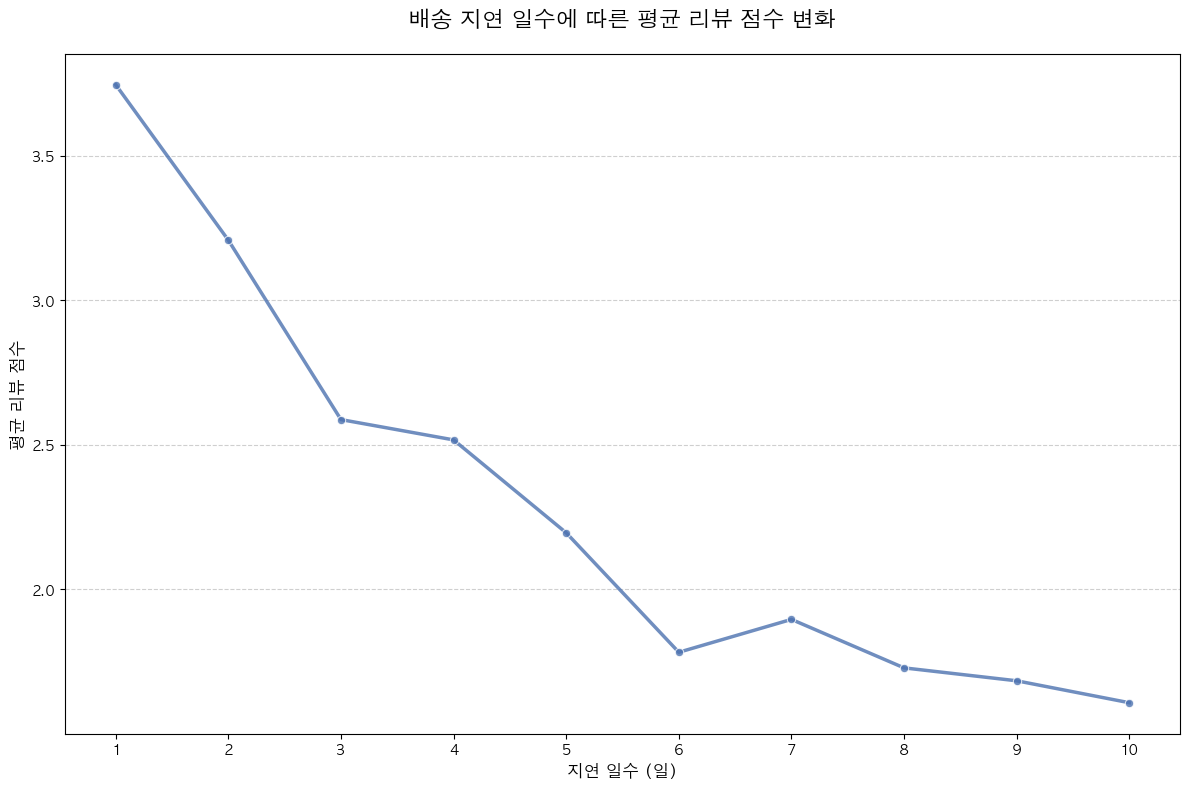

In [87]:
# delay_days 가 x축, review_score 가 y축 --> 꺾은선 그래프 line plot

plt.figure(figsize=(12, 8))

# 1. 데이터 준비 (지연 1~10일 데이터만 필터링 및 평균 계산)
data_filtered = df2[(df2['delay_days_int'] > 0) & (df2['delay_days_int'] <= 10)].copy()
plot_data = data_filtered.groupby('delay_days_int')['review_score'].mean().reset_index()

# 2. 꺾은선 그래프 그리기
sns.lineplot(
    data=plot_data, 
    x='delay_days_int', 
    y='review_score', 
    marker='o',        
    color="#4C72B0",   
    linewidth=2.5, 
    alpha=0.8
)

# 3. 그래프 스타일링 (가독성 향상)
plt.title('배송 지연 일수에 따른 평균 리뷰 점수 변화', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('지연 일수 (일)', fontsize=12)
plt.ylabel('평균 리뷰 점수', fontsize=12)
plt.xticks(range(1, 11))  # x축 눈금을 1일 단위로 표시
plt.grid(True, axis='y', linestyle='--', alpha=0.6) # 가로 그리드 추가

plt.tight_layout()
plt.show()

위의 꺾은선 그래프를 보아 지연일이 3일, 6일, 9일인 지점에서 큰 변화가 일어난다고 보여져서 기준을 3일, 6일, 9일으로 잡았다

In [88]:
# delay_days를 카테고리화
def delay_days_cat(x):
    if x < 0:
         return '조기'
    elif x == 0:
         return '정시'
    elif x <= 3: 
        return '1-3일 지연'
    elif x <= 6: 
        return '4-6일 지연'
    elif x <= 9:
        return '7-9일 지연'
    else: 
        return '10일 이상 지연'

df2['delay_days_cat'] = df2['delay_days'].apply(delay_days_cat)

In [89]:
df2['delay_days_cat'].value_counts()

delay_days_cat
조기           100648
1-3일 지연        2908
10일 이상 지연      2665
4-6일 지연        1545
7-9일 지연        1332
정시              196
Name: count, dtype: int64

In [90]:
df2.info()

<class 'pandas.DataFrame'>
Index: 109294 entries, 0 to 109295
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   index                          109294 non-null  int64         
 1   order_id                       109294 non-null  str           
 2   customer_id                    109294 non-null  str           
 3   order_purchase_timestamp       109294 non-null  datetime64[us]
 4   order_approved_at              109294 non-null  datetime64[us]
 5   order_delivered_carrier_date   109294 non-null  datetime64[us]
 6   order_delivered_customer_date  109294 non-null  datetime64[us]
 7   order_estimated_delivery_date  109294 non-null  datetime64[us]
 8   customer_unique_id             109294 non-null  str           
 9   customer_zip_code_prefix       109294 non-null  int64         
 10  customer_city                  109294 non-null  str           
 11  customer_state  

In [91]:
df2.rename(columns={'product_category_name_english': 'category'}, inplace=True)

In [92]:
cols = df2.columns
cols

Index(['index', 'order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'customer_lat', 'customer_lng', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'review_id', 'review_score', 'review_answer_timestamp',
       'category', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_lat', 'seller_lng', 'order_purchase_dayofweek',
       'order_purchase_month', 'approved_days', 'dispatch_days',
       'delivery_days', 'expected_delivery_days', 'delay_days',
       'delay_days_int', 'is_delayed', 'delay_days_cat'],
      dtype='str')

In [93]:
delete_cols = ['index','order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date',
                'order_estimated_delivery_date','product_id','review_id','review_answer_timestamp']
df2 = df2.drop(delete_cols, axis=1)

In [94]:
cols = df.columns 
cols

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'customer_lat', 'customer_lng', 'order_item_id',
       'product_id', 'seller_id', 'shipping_limit_date', 'price',
       'freight_value', 'review_id', 'review_score', 'review_answer_timestamp',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'seller_lat', 'seller_lng'],
      dtype='str')

### 카테고리 범주화 (메인/서브)

In [95]:
def map_to_main_category(cat):
    # 대분류 매핑 사전 정의
    mapping = {
        # 1. 홈 & 리빙 (Home & Living)
        'bed_bath_table': 'Home & Living', 'furniture_decor': 'Home & Living', 
        'housewares': 'Home & Living', 'office_furniture': 'Home & Living',
        'home_confort': 'Home & Living', 'home_comfort_2': 'Home & Living',
        'furniture_living_room': 'Home & Living', 'furniture_bedroom': 'Home & Living',
        'furniture_mattress_and_upholstery': 'Home & Living', 'home_appliances': 'Home & Living',
        'home_appliances_2': 'Home & Living', 'small_appliances': 'Home & Living',
        'small_appliances_home_oven_and_coffee': 'Home & Living', 'air_conditioning': 'Home & Living',
        'kitchen_dining_laundry_garden_furniture': 'Home & Living', 'la_cuisine': 'Home & Living',

        # 2. 헬스, 뷰티 & 패션 (Health, Beauty & Fashion)
        'health_beauty': 'Health & Beauty & Fashion', 'perfumery': 'Health & Beauty & Fashion',
        'diapers_and_hygiene': 'Health & Beauty & Fashion', 'watches_gifts': 'Health & Beauty & Fashion',
        'fashion_bags_accessories': 'Health & Beauty & Fashion', 'luggage_accessories': 'Health & Beauty & Fashion',
        'fashion_shoes': 'Health & Beauty & Fashion', 'fashion_underwear_beach': 'Health & Beauty & Fashion',
        'fashion_male_clothing': 'Health & Beauty & Fashion', 'fashio_female_clothing': 'Health & Beauty & Fashion',
        'fashion_sport': 'Health & Beauty & Fashion', 'fashion_childrens_clothes': 'Health & Beauty & Fashion',

        # 3. 디지털 & 테크 (Electronics & Tech)
        'computers_accessories': 'Electronics & Tech', 'computers': 'Electronics & Tech',
        'tablets_printing_image': 'Electronics & Tech', 'telephony': 'Electronics & Tech',
        'fixed_telephony': 'Electronics & Tech', 'electronics': 'Electronics & Tech',
        'audio': 'Electronics & Tech', 'cine_photo': 'Electronics & Tech',

        # 4. 취미, 레저 & 키즈 (Leisure & Kids)
        'toys': 'Leisure & Kids', 'baby': 'Leisure & Kids', 'sports_leisure': 'Leisure & Kids',
        'books_general_interest': 'Leisure & Kids', 'books_technical': 'Leisure & Kids',
        'books_imported': 'Leisure & Kids', 'consoles_games': 'Leisure & Kids',
        'dvds_blu_ray': 'Leisure & Kids', 'music': 'Leisure & Kids',
        'cds_dvds_musicals': 'Leisure & Kids', 'art': 'Leisure & Kids',
        'arts_and_craftmanship': 'Leisure & Kids', 'cool_stuff': 'Leisure & Kids',
        'party_supplies': 'Leisure & Kids', 'christmas_supplies': 'Leisure & Kids',

        # 5. 공구, 가든 & 산업 (DIY & Industry)
        'garden_tools': 'DIY & Industry', 'costruction_tools_garden': 'DIY & Industry',
        'flowers': 'DIY & Industry', 'agro_industry_and_commerce': 'DIY & Industry',
        'construction_tools_construction': 'DIY & Industry', 'home_construction': 'DIY & Industry',
        'construction_tools_lights': 'DIY & Industry', 'construction_tools_safety': 'DIY & Industry',
        'costruction_tools_tools': 'DIY & Industry', 'signaling_and_security': 'DIY & Industry',
        'industry_commerce_and_business': 'DIY & Industry', 'stationery': 'DIY & Industry',

        # 6. 기타 (Others)
        'auto': 'Others', 'food': 'Others', 'food_drink': 'Others', 'drinks': 'Others',
        'pet_shop': 'Others', 'market_place': 'Others', 'security_and_services': 'Others'
    }
    
    # 매핑 사전에 없으면 'Others'로 반환
    return mapping.get(cat, 'Others')

# 'category' 컬럼을 기준으로 'main_category' 컬럼을 생성합니다.
df2['main_category'] = df2['category'].apply(map_to_main_category)

# 결과 확인
print(df2['main_category'].value_counts())

main_category
Home & Living                30645
Health & Beauty & Fashion    22210
Leisure & Kids               21457
Electronics & Tech           15673
DIY & Industry                9688
Others                        9621
Name: count, dtype: int64


In [96]:
def map_to_sub_category(cat):
    # 중분류 매핑 사전 정의
    mapping = {
        # --- Home & Living 계열 ---
        'bed_bath_table': 'Furniture & Decor', 'furniture_decor': 'Furniture & Decor',
        'office_furniture': 'Furniture & Decor', 'furniture_living_room': 'Furniture & Decor',
        'furniture_bedroom': 'Furniture & Decor', 'furniture_mattress_and_upholstery': 'Furniture & Decor',
        'housewares': 'Kitchen & Housewares', 'la_cuisine': 'Kitchen & Housewares',
        'kitchen_dining_laundry_garden_furniture': 'Kitchen & Housewares',
        'home_appliances': 'Home Appliances', 'home_appliances_2': 'Home Appliances',
        'small_appliances': 'Home Appliances', 'small_appliances_home_oven_and_coffee': 'Home Appliances',
        'air_conditioning': 'Home Appliances',
        'home_confort': 'Home Interior', 'home_comfort_2': 'Home Interior',

        # --- Health, Beauty & Fashion 계열 ---
        'health_beauty': 'Health & Beauty', 'perfumery': 'Health & Beauty', 'diapers_and_hygiene': 'Health & Beauty',
        'watches_gifts': 'Fashion Accessories', 'fashion_bags_accessories': 'Fashion Accessories',
        'luggage_accessories': 'Fashion Accessories',
        'fashion_shoes': 'Clothing & Shoes', 'fashion_underwear_beach': 'Clothing & Shoes',
        'fashion_male_clothing': 'Clothing & Shoes', 'fashio_female_clothing': 'Clothing & Shoes',
        'fashion_sport': 'Clothing & Shoes', 'fashion_childrens_clothes': 'Clothing & Shoes',

        # --- Electronics & Tech 계열 ---
        'computers_accessories': 'IT & Computers', 'computers': 'IT & Computers', 'tablets_printing_image': 'IT & Computers',
        'telephony': 'Telephony', 'fixed_telephony': 'Telephony',
        'electronics': 'Electronics', 'audio': 'Electronics', 'cine_photo': 'Electronics',

        # --- Leisure & Kids 계열 ---
        'toys': 'Kids & Baby', 'baby': 'Kids & Baby',
        'sports_leisure': 'Sports & Leisure',
        'books_general_interest': 'Books & Media', 'books_technical': 'Books & Media', 'books_imported': 'Books & Media',
        'dvds_blu_ray': 'Books & Media', 'music': 'Books & Media', 'cds_dvds_musicals': 'Books & Media',
        'consoles_games': 'Games & Hobbies', 'art': 'Games & Hobbies', 'arts_and_craftmanship': 'Games & Hobbies',
        'cool_stuff': 'Games & Hobbies', 'party_supplies': 'Games & Hobbies', 'christmas_supplies': 'Games & Hobbies',

        # --- DIY, Garden & Industry 계열 ---
        'garden_tools': 'Garden & Agro', 'costruction_tools_garden': 'Garden & Agro',
        'flowers': 'Garden & Agro', 'agro_industry_and_commerce': 'Garden & Agro',
        'construction_tools_construction': 'Tools & Construction', 'home_construction': 'Tools & Construction',
        'construction_tools_lights': 'Tools & Construction', 'construction_tools_safety': 'Tools & Construction',
        'costruction_tools_tools': 'Tools & Construction', 'signaling_and_security': 'Tools & Construction',
        'industry_commerce_and_business': 'Industry & Office', 'stationery': 'Industry & Office',

        # --- Others ---
        'auto': 'Automotive',
        'food': 'Food & Drink', 'food_drink': 'Food & Drink', 'drinks': 'Food & Drink',
        'pet_shop': 'Pet Shop',
        'market_place': 'Others', 'security_and_security': 'Others'
    }
    
    # 매핑 사전에 없으면 'Others'로 반환
    return mapping.get(cat, 'Others')

df2['sub_category'] = df2['category'].apply(map_to_sub_category)

# 중분류 확인
df2['sub_category'].value_counts()

sub_category
Furniture & Decor       21171
Health & Beauty         12766
Fashion Accessories      8860
Sports & Leisure         8373
IT & Computers           7882
Kitchen & Housewares     7032
Kids & Baby              6955
Games & Hobbies          5166
Garden & Agro            4705
Telephony                4654
Automotive               4097
Electronics              3137
Industry & Office        2712
Others                   2494
Tools & Construction     2271
Home Appliances          1990
Pet Shop                 1913
Food & Drink             1117
Books & Media             963
Clothing & Shoes          584
Home Interior             452
Name: count, dtype: int64

### 위도 경도 활용해서 거리 파생변수 생성

In [97]:
# Haversine 거리 계산 함수 (지구 곡률을 반영한 두 좌표 간의 직선 거리 km)
def haversine_vectorize(lat1, lon1, lat2, lon2):
    # 라디안 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c # 6371: 지구의 평균 반지름(km)
    return km

# 거리(distance_km) 파생 변수 생성
df2['distance_km'] = haversine_vectorize(
    df2['customer_lat'], df2['customer_lng'],
    df2['seller_lat'], df2['seller_lng']
)

In [98]:
df2.isna().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_zip_code_prefix       0
customer_city                  0
customer_state                 0
customer_lat                  49
customer_lng                  49
order_item_id                  0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
review_score                   0
category                    1545
seller_zip_code_prefix         0
seller_city                    0
seller_state                   0
seller_lat                     0
seller_lng                     0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
delay_days_int                 0
is_delayed                     0
delay_days_cat                 0
main_categ

#### 거리 파생변수 결측치 처리

In [99]:
df2['distance_km'] = df2['distance_km'].fillna(df2['distance_km'].median()) # 거리 중앙값으로 대체

# 모델 학습에 불필요한 중간 컬럼 삭제
cols_to_drop = ['customer_zip_code_prefix', 'seller_zip_code_prefix', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
df2 = df2.drop(columns=cols_to_drop)

#### 브라질 물류 특성을 반영한 거리 파생변수 범주화

In [100]:
# 브라질 물류 특성을 반영한 경계값 설정
# 0-50(도시내), 50-250(인접도시), 250-750(핵심노선), 750-1500(지역간), 1500+(초장거리)
def distance_cat(x):
    if x <= 50:
        return "Urban/Last-Mile"
    elif x <=250 :
        return "Short-Haul"
    elif x <= 750:
        return "Mid-Haul"
    elif x <= 1500:
        return "Long-Haul"
    else:
        return "Continental"
    
df2['distance_cat'] = df2['distance_km'].apply(distance_cat)

# 각 구간에 데이터가 골고루 분포되었는지 확인
print(df2['distance_cat'].value_counts().sort_index())

distance_cat
Continental         9729
Long-Haul          19790
Mid-Haul           48704
Short-Haul         17689
Urban/Last-Mile    13382
Name: count, dtype: int64


#### 판매자와 구매자의 지역이 다른지 여부를 나타내는 파생변수 생성

In [101]:
df2["cross_state"] = (df2["customer_state"] != df2["seller_state"]).astype(int)

In [102]:
cols = df2.columns
cols

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_item_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'review_score', 'category', 'seller_city',
       'seller_state', 'order_purchase_dayofweek', 'order_purchase_month',
       'approved_days', 'dispatch_days', 'delivery_days',
       'expected_delivery_days', 'delay_days', 'delay_days_int', 'is_delayed',
       'delay_days_cat', 'main_category', 'sub_category', 'distance_km',
       'distance_cat', 'cross_state'],
      dtype='str')

In [103]:
df2.info()

<class 'pandas.DataFrame'>
Index: 109294 entries, 0 to 109295
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   order_id                  109294 non-null  str     
 1   customer_id               109294 non-null  str     
 2   customer_unique_id        109294 non-null  str     
 3   customer_city             109294 non-null  str     
 4   customer_state            109294 non-null  str     
 5   order_item_id             109294 non-null  int64   
 6   seller_id                 109294 non-null  str     
 7   shipping_limit_date       109294 non-null  str     
 8   price                     109294 non-null  float64 
 9   freight_value             109294 non-null  float64 
 10  review_score              109294 non-null  int64   
 11  category                  107749 non-null  str     
 12  seller_city               109294 non-null  str     
 13  seller_state              109294 non-null  st

In [104]:
df2.isna().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_item_id                  0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
review_score                   0
category                    1545
seller_city                    0
seller_state                   0
order_purchase_dayofweek       0
order_purchase_month           0
approved_days                  0
dispatch_days                  0
delivery_days                  0
expected_delivery_days         0
delay_days                     0
delay_days_int                 0
is_delayed                     0
delay_days_cat                 0
main_category                  0
sub_category                   0
distance_km                    0
distance_cat                   0
cross_state                    0
dtype: int64

In [105]:
df2.to_csv('./data/merged_final_data.csv', index=False)

우리가 eda와 별개로 깔끔하게 사용하려고 정리한 최종 데이터는 merged_final_data.csv

머신러닝 들어가기 전에는 merged_final_data를 불러와서 split 코드를 추가하고

그 상태에서 훈련하고 테스트 하면 되는 것!!!!

eda 진행할 때에도 데이터 누수가 발생하면 안되므로 train_validation / test 셋으로 나누어서

훈련_검증 데이터셋으로만 eda 진행!!!